<a href="https://colab.research.google.com/github/donkey-king-kong/CSCI-4907---NLU/blob/main/(GWU)_CSCI_4907_NLU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning
Machine learning is a branch of artificial intelligence that focuses on developing algorithms and statistical models that allow us to learn from our data and make any predicitons or decisions without explicitly programming it. 

Machine learning can identify patterns across large datasets that is impossible for the human to do so efficiently. The machine's performance can also be improved over time as they are more exposed to more data or by fine-tuning certain parameters.

## Load all relevant artifacts

In [3]:
import joblib
import torch

# Load train-test split
x_train = joblib.load(r"..\Artifacts\x_train.pkl")
x_test = joblib.load(r"..\Artifacts\x_test.pkl")
y_train = joblib.load(r"..\Artifacts\y_train.pkl")
y_test = joblib.load(r"..\Artifacts\y_test.pkl")
class_names = joblib.load(r"..\Artifacts\class_names.pkl")

print("Data split loaded")

# Load Naive Bayes
svm_model = joblib.load(r"..\Artifacts\svm_model.pkl")
svm_vectorizer = joblib.load(r"..\Artifacts\svm_vectorizer.pkl")


print("SVM model loaded")
print("SVM Vectorizer loaded")

Data split loaded
SVM model loaded
SVM Vectorizer loaded


### Classifier Report Function

In [4]:
def Classifier(
    model=None,
    mode="train",
    model_path="model.pkl",
    vectorizer_path="vectorizer.pkl"
):
    """
    mode="train" -> train model and save model + vectorizer
    mode="load"  -> load saved model + vectorizer, no retraining
    """

    if mode == "train":
        # Create and fit TF-IDF vectorizer on training data only
        vectorizer = TfidfVectorizer()
        x_train_vecs = vectorizer.fit_transform(x_train)
        x_test_vecs = vectorizer.transform(x_test)

        model.fit(x_train_vecs, y_train)

        # Save trained model and fitted vectorizer
        joblib.dump(model, model_path)
        joblib.dump(vectorizer, vectorizer_path)

        print(f"Saved model to: {model_path}")
        print(f"Saved vectorizer to: {vectorizer_path}")

    elif mode == "load":
        # Load saved model and fitted vectorizer
        model = joblib.load(model_path)
        vectorizer = joblib.load(vectorizer_path)

        # Transform test text using loaded vectorizer
        x_test_vecs = vectorizer.transform(x_test)

        print(f"Loaded model from: {model_path}")
        print(f"Loaded vectorizer from: {vectorizer_path}")

    else:
        raise ValueError("Mode must be 'train' or 'load'")

    y_pred = model.predict(x_test_vecs)

    print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred)))
    print()
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Plot confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    sb.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap=None,
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return model, vectorizer, y_pred

### **Support Vector Machine**

SVM classification finds the best hyperplane to separate data into different classes, maximizing the margin between them. It's effective for various classification tasks due to its ability to handle linear and non-linear separations through kernel functions.

Saved model to: .\Artifacts\svm_model.pkl
Saved vectorizer to: .\Artifacts\svm_vectorizer.pkl
Accuracy: 0.814

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      1952
           1       0.97      0.98      0.97      1995
           2       0.92      0.81      0.86      1952
           3       0.59      0.48      0.53      2040
           4       0.55      0.70      0.62      2006
           5       0.96      0.94      0.95      1978

    accuracy                           0.81     11923
   macro avg       0.82      0.82      0.82     11923
weighted avg       0.82      0.81      0.81     11923



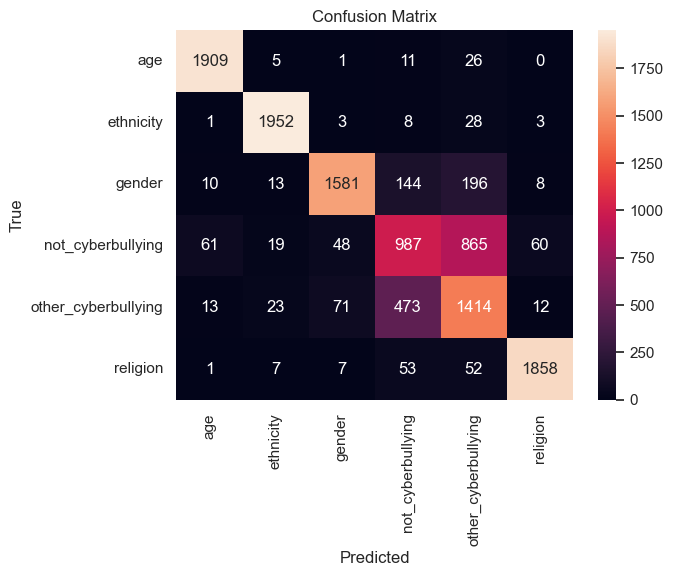

In [ ]:
from sklearn.svm import SVC

model = SVC(probability=True)

svm_model, svm_vectorizer, svm_y_pred = Classifier(
    model=model,
    mode="train",
    model_path=r".\Artifacts\svm_model.pkl",
    vectorizer_path=r".\Artifacts\svm_vectorizer.pkl"
)

**ROC Curve**

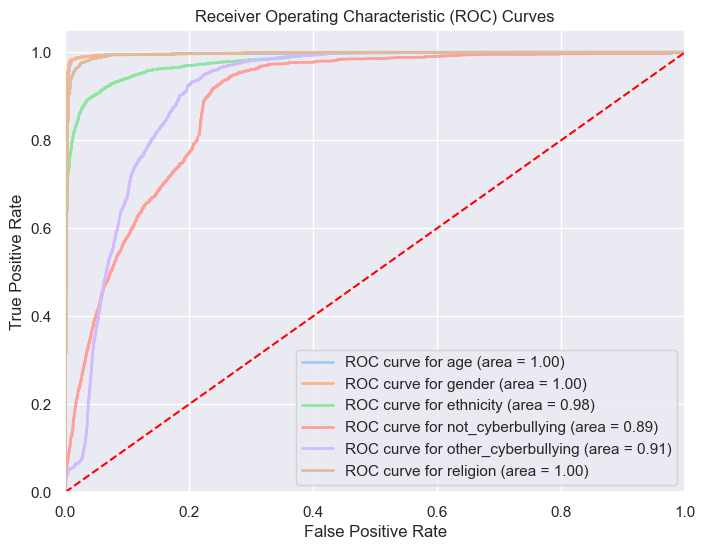

In [ ]:
plot_roc_curves(model, x_test_vecs, y_test)

**Learning Curve**

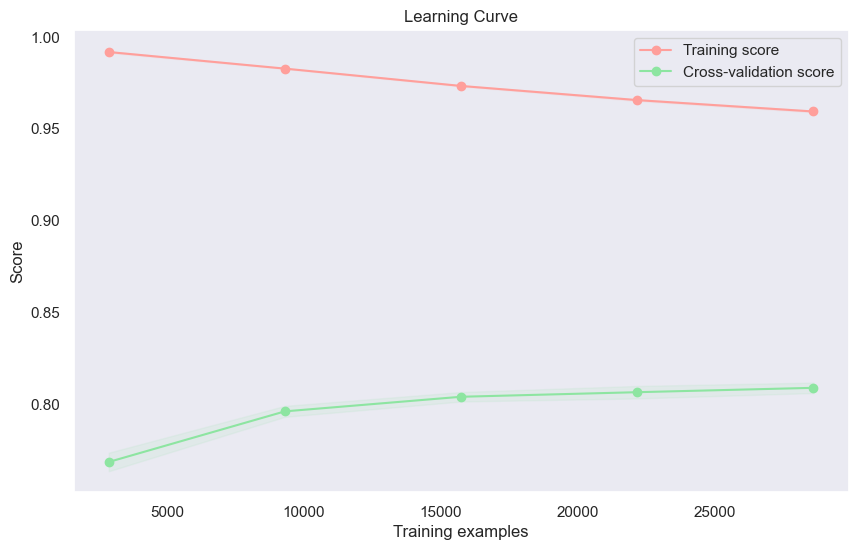

In [ ]:
plot_learning_curve_multi_class(model, x_train_vecs, y_train, class_labels)

*ADVANTAGES*

- Performs well even in high-dimensional spaces, making it suitable for complex datasets.

- Aims to maximize the margin between classes, leading to a more generalizable model and reducing the risk of overfitting.

- Can handle non-linear decision boundaries using kernel functions like polynomial, radial basis function (RBF), and sigmoid, providing flexibility in modeling complex relationships.

*DISADVANTAGES*

- Training models can be computationally intensive, especially for large datasets.

- SVM is sensitive to noisy data and outliers, which can affect the placement of the decision boundary and degrade performance.

- The decision boundary produced by SVM may be difficult to interpret, especially in higher dimensions or with non-linear kernels, making it challenging to understand the underlying relationships in the data.